In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from tqdm import tqdm
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction
While VAEs have shown great performance (via approximate maximum likelihood) and noteworthy generation, the geometry of the latent space is typically unconstrained and is only tied to the dataset by providing a structure that maximizes $p_\theta(x)$. This structure can change across different instances of training. In other words, the latent space is not *identifiable*. A model is identifiable if $$p_\theta(x) = p_{\theta'}(x) \Rightarrow \theta = \theta'$$ for all $(x,z)$ and parameter pairs $(\theta, \theta')$.

To address this issue, iVAE was introduced in the 2020 paper "Variational autoencoders and nonlinear ICA: A unifying framework" by Khemakhem et al. It assumes a factorized distribution $$p(x, z, u) = p(u)p(z|u)p(x|z),$$ where $x$ is observed data, $u$ is an auxiliary label, and $z$ is the latent space. The auxiliary variable $u$ provides a frame of reference for the latent space so the model is identifiable (up to affine transformations) across different training sessions. 

The original iVAE model is reproduced in this chapter and we use it as a baseline to compare to ablation tests in the next chapters.

# Model definitions

### Utility functions

In [2]:
# Log likelihood of multivariate normal distribution with diagonal covariance
def normal_ll(x, mu, logvar):
    const = -x.shape[-1] * torch.tensor(2*torch.pi).log()
    ll = -0.5 * (const + logvar + (x - mu).pow(2) / logvar.exp()).sum(-1)
    return ll

In [3]:
# Monte Carlo samples for reparameterization trick
def sample(mu, logvar):
    z = mu + (0.5 * logvar).exp() * torch.randn_like(mu)
    return z

### MLP network

In [4]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, mu_flag=True, var_flag=True):
        super().__init__()
        self.mu_flag = mu_flag    # mu may be learned or fixed to a constant
        self.var_flag = var_flag  # logvar may be learned or fixed to a constant
        hidden = 50

        self.layers = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.LeakyReLU(1e-2),    # LeakyReLU is used to facilitate the injective mapping from Z to X
            nn.Linear(hidden, hidden),
            nn.LeakyReLU(1e-2)
        )
        
        if self.mu_flag:
            self.mu = nn.Linear(hidden, out_dim)
        if self.var_flag:
            self.logvar = nn.Linear(hidden, out_dim)

    def forward(self, x):
        out = self.layers(x)
        if self.mu_flag and self.var_flag:
            return self.mu(out), self.logvar(out)
        if self.mu_flag:
            return self.mu(out)
        if self.var_flag:
            return self.logvar(out)

### iVAE model

In [5]:
class iVAE_Base(nn.Module):
    def __init__(self, kx, ku, **kwargs):
        super().__init__()

        pz = 2  # dimensionality of latent space

        # Prior p(z|u)
        self.mu_prior = torch.zeros(pz)  # prior mean fixed to zero
        self.prior_logvar = MLP(ku, pz, mu_flag=False)

        # Encoder q(z|x,u)
        self.encoder_mu = MLP(kx + ku, pz, var_flag=False)
        self.encoder_logvar = MLP(kx + ku, pz, mu_flag=False)
        
        # Decoder p(x|z)
        self.decoder_mu = MLP(pz, kx, var_flag=False)
        noise = torch.tensor(0.01)
        self.logvar_p = noise.log() * torch.ones(kx)  # decoder covariance fixed to 0.01

    def forward(self, x, u):
        xu = torch.cat((x, u), 1)
        # Prior parameters
        self.logvar_prior = self.prior_logvar(u)

        # Encoder parameters
        self.mu_q = self.encoder_mu(xu)
        self.logvar_q = self.encoder_logvar(xu)

        # Reparameterization trick
        z = sample(self.mu_q, self.logvar_q)
        self.z = z

        # Decoder parameters
        self.mu_p = self.decoder_mu(z)

        return self.mu_p, self.logvar_p, self.mu_prior, self.logvar_prior, self.mu_q, self.logvar_q

    def loss(self, x):
        mu_prior = self.mu_prior.expand(x.shape[0], -1)
        px_z = normal_ll(x, self.mu_p.to(device), self.logvar_p.to(device))          # log p(x|z)
        qz_xu = normal_ll(self.z, self.mu_q.to(device), self.logvar_q.to(device))    # log p(z|x,u)
        pz_u = normal_ll(self.z, mu_prior.to(device), self.logvar_prior.to(device))  # log p(z|u)
        return px_z.mean(), qz_xu.mean(), pz_u.mean()

    def get_z_samples(self):
        return self.z

# Metrics of evaluation

### Active units
This measures "useful" latents by how much variance the latents have to different inputs. Low variance is an indicator of posterior collapse, i.e. the latents do not depend on the data.
From "Importance weighted autoencoder", Burda et al, 2016.

In [6]:
def active_units(mu_q, thresh=1e-3):
    au_var = mu_q.var(0)
    au = au_var > thresh
    return au.detach().cpu().numpy(), au_var.detach().cpu().numpy()

### Mean correlation coefficient
Measures how close estimated latents are to ground truth latents by Pearson correlation between z_true and z_hat (the closer to 1, the better). Provides optimal latent dimension matching via linear sum assignment. From "Variational autoencoders and nonlinear ICA: A unifying framework", Khemakhem et al, 2020.

In [7]:
from scipy.optimize import linear_sum_assignment

def mcc(z_true, mu_q, logvar_q):
    dim = mu_q.shape[1]
    z_hat = mu_q + torch.exp(0.5*logvar_q) * torch.randn_like(mu_q)
    z_hat = z_hat.detach().cpu().numpy()
    z_true = z_true.detach().cpu().numpy()
    mcc_mat = np.zeros((dim, dim))
    for i in range(dim):
        for j in range(dim):
            mcc_mat[i, j] = np.corrcoef(z_true[:, j], z_hat[:, i])[0, 1]

    row_idx, col_idx = linear_sum_assignment(1-abs(mcc_mat))
    mapping = list(col_idx)
    return mcc_mat, mapping

### Mutual information I(X;Z)
Estimates the approximate mutual information I(X;Z) under joint distribution q(X,Z) = p(X) q(Z|X). Used in "Posterior collapse and latent variable non-identifiability", Wang et al, 2021.

In [8]:
def approximate_mi(mu, logvar, z):
    k = mu.shape[0]
    z = z[:, None, :]
    mu = mu[None, :, :]
    logvar = logvar[None, :, :]

    log_qz_x = normal_ll(z, mu, logvar)
    log_qz = torch.logsumexp(log_qz_x, dim=1) - np.log(k)
    log_qz_x_diag = log_qz_x.diag()

    ami = (log_qz_x_diag - log_qz).mean()
    return ami.item()

# Training

### Prepare for training

In [9]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [10]:
# General training settings
cfg = {
    'rng': 1,
    'batch_size': 64,
    'epochs': 5,
    'lr': 0.001,
    'data_src': 'ivae1'
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

In [11]:
# Load dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

In [12]:
# Initialize structures for saving loss
recon = []
kl = []

In [13]:
# Define model
ku = 40
model = iVAE_Base(kx, ku).to(device)
optimizer = torch.optim.Adam(params=model.parameters(), lr=cfg['lr'])
n_parameters = sum(param.numel() for param in model.parameters())
print("Number of parameters: " + str(n_parameters))

# NOTE: original iVAE includes a scheduler. It makes training smoother but slower with the same outcome, so we omit it here
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.1, patience=4)

Number of parameters: 17410


### Training loop

In [14]:
acc_arr = []
mi_arr = []

for epoch in tqdm(range(cfg['epochs'])):

    for batch in train_loader:
        # Forward pass
        x, u = util.get_batch(batch, cfg['data_src'], device)
        output = model(x, u)

        # # Measure accuracy
        # u_events = u.shape[-1]
        # pred, ll = decode_lbl(model, x, u_events)
        # acc = (pred == torch.argmax(u, dim=1)).int().sum() / u.shape[0]
        # acc_arr.append(acc)

        # Calculate mutual information
        zs = model.get_z_samples()
        ami = util.approximate_mi(output[-2], output[-1], zs)
        mi_arr.append(ami)

        # Update model, compute loss
        optimizer.zero_grad()
        losses = model.loss(x)
        recon_loss = -losses[0]
        kl_loss = losses[1] - losses[2]
        loss = recon_loss + kl_loss
        loss.backward()
        optimizer.step()

        # Save losses
        recon.append(recon_loss.item())
        kl.append(kl_loss.item())


100%|██████████| 5/5 [00:08<00:00,  1.63s/it]


# Evaluation

### Plot training loss

Final reconstruction loss: -20.097
Final KL loss: 3.858


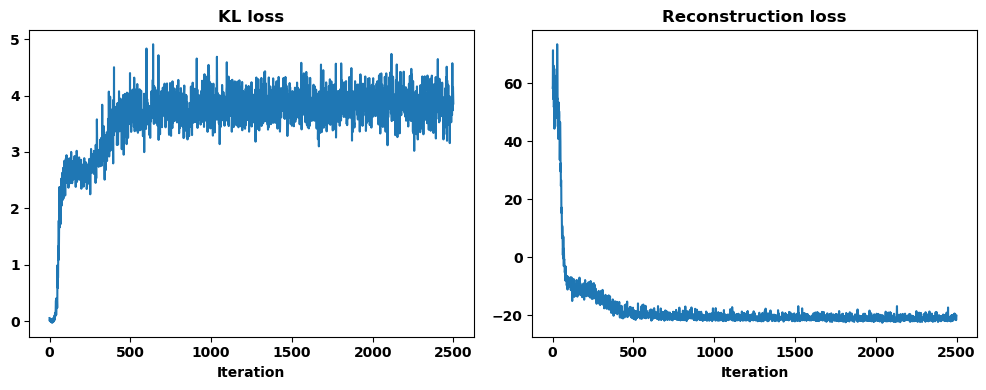

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# KL loss
axs[0].plot(kl)
axs[0].set_xlabel("Iteration")
axs[0].set_title("KL loss")
# Reconstruction loss
axs[1].plot(recon)
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.tight_layout()

print(f"Final reconstruction loss: {recon[-1]:.3f}")
print(f"Final KL loss: {kl[-1]:.3f}")

### Plot mutual information I(X;Z)

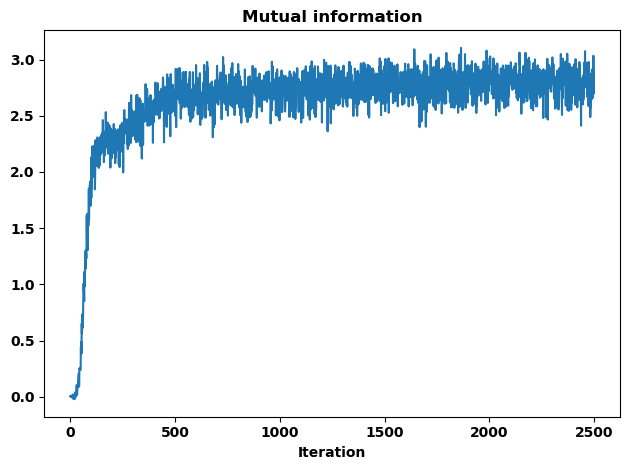

In [16]:
plt.plot(mi_arr)
plt.xlabel("Iteration")
plt.title("Mutual information")
plt.tight_layout()

### Active units and MCC

In [17]:
x, u, z = zip(*test_data)
x = torch.stack(list(x))
u = torch.stack(list(u))
z = torch.stack(list(z))

model.eval()
with torch.no_grad():
    x, u = x.to(device), u.to(device)
    output = model(x, u)

    z_samp = model.get_z_samples()
    mu_prior = output[2]
    logvar_prior = output[3]
    mu_q = output[-2]
    logvar_q = output[-1]
    
    test_losses = model.loss(x)
    recon_loss = -test_losses[0]
    kl_loss = test_losses[1]-test_losses[2]
    print(f"Test reconstruction loss: {recon_loss:.3f}")
    print(f"Test KL loss: {kl_loss:.3f}")

    au, au_var = active_units(mu_q)
    mcc_mat, mapping = mcc(z, mu_q, logvar_q)

    ami = util.approximate_mi(mu_q, logvar_q, z_samp)
    print("Approximate mutual information: " + str(ami))

    pz = len(au)
    for i in range(pz):
        print(f"Latent {i}\n\tActive: {au[i]}. Variance: {au_var[i]:.3f}\
                \n\tMCC: {mcc_mat[i, mapping.index(i)]:.3f}"
             )

Test reconstruction loss: -21.153
Test KL loss: 3.890
Approximate mutual information: 3.0258631706237793
Latent 0
	Active: True. Variance: 4.785                
	MCC: -0.879
Latent 1
	Active: False. Variance: 0.001                
	MCC: -0.004
